# Evaluación práctica · Machine Learning · 3 puntos

**Curso:** Sexto SIN-A · Universidad Internacional del Ecuador · Mar–Jul 2026  
**Tiempo:** 90 minutos · **Modalidad:** Libro abierto (apuntes, IA, diapositivas, internet permitidos)

---

## ⚠️ Lea esto ANTES de empezar

Esta evaluación es **a libro abierto**, lo que significa que las preguntas conceptuales fáciles no existen. Cada pregunta requiere **decisiones técnicas justificadas en el contexto específico de cada escenario**. ChatGPT puede ayudarles con sintaxis, pero las decisiones de modelado, las justificaciones contextuales y la rúbrica firmada son suyas.

## Reglas de entrega

1. **Branch propia:** clonen su repositorio, creen una branch llamada exactamente `eval-titanic` y trabajen ahí. No hagan merge a `metrics` ni a `main`.
2. **Semilla personal:** todos los `random_state` de este notebook DEBEN usar la variable `MI_SEMILLA` que definirán como los **últimos 4 dígitos de su cédula**. Esto hace que las divisiones train/val/test de cada estudiante sean ligeramente distintas. Quien copie números de otro será detectable.
3. **Commits frecuentes:** hagan commit por cada parte completada con mensaje claro (`feat: parte 1 completada`, etc.). El historial de commits es parte de la evaluación.
4. **Push al terminar:** hagan `git push origin eval-titanic` cuando terminen. El timestamp del último commit en GitHub es la hora oficial de entrega.
5. **Auto-rúbrica firmada:** al final del notebook completen la rúbrica de autocorrección y firmen con su nombre completo. Sin firma, la entrega no se considera válida.

## Puntuación

| Parte | Tema | Puntos |
|---|---|---|
| 1 | Pipeline completo aplicado a Titanic | 1.5 |
| 2 | Find the bug + Predict the output | 0.75 |
| 3 | Trade-offs de negocio escritos | 0.75 |
| **Total** | | **3.0** |

---

In [1]:
# Imports — NO modificar esta celda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

## 🔑 Semilla personal (OBLIGATORIO)

Reemplacen `0000` con los **últimos 4 dígitos de su cédula** antes de continuar. Esta semilla se usa en TODOS los `random_state` del notebook.

In [2]:
# REEMPLAZAR CON ÚLTIMOS 4 DÍGITOS DE SU CÉDULA
MI_SEMILLA = 1698  # ← cambiar aquí

# Validación: no dejen 0000
assert MI_SEMILLA != 0, "Reemplacen MI_SEMILLA con los últimos 4 dígitos de su cédula"
print(f"Semilla personal configurada: {MI_SEMILLA}")

Semilla personal configurada: 1698


---

# 📊 PARTE 1 — Pipeline completo aplicado (1.5 puntos · ~50 min)

## Escenario de negocio

**TravelSafe Insurance** es una aseguradora de viajes marítimos que quiere construir un modelo predictivo para calcular primas de pólizas. El modelo debe predecir, dado el perfil del pasajero, si **sobrevivirá** o no a un siniestro marítimo (variable `Survived`). 

Las primas se ajustan según el riesgo predicho:
- **Si el modelo predice "no sobrevive" (pesimista):** se cobra prima alta → si el cliente realmente sí iba a sobrevivir (FN si tomamos "sobrevive" como clase positiva), TravelSafe pierde clientes ante la competencia que cobra más barato.
- **Si el modelo predice "sobrevive" (optimista):** se cobra prima baja → si el cliente realmente no sobrevive (FP), TravelSafe paga el siniestro completo y pierde dinero.

Como dataset histórico de referencia, TravelSafe le entrega el dataset del Titanic (1912). Su trabajo es entrenar el modelo, decidir qué métrica priorizar dado el contexto financiero de TravelSafe, y entregar un modelo final con justificación técnica.

> **Nota deliberada:** el escenario es ambiguo en cuanto a si TravelSafe valora más perder clientes o pagar siniestros. **Ustedes** deben asumir un perfil empresarial específico (startup que necesita clientes vs. aseguradora establecida que minimiza riesgo) y justificarlo.

---

## 1.1 Carga y exploración inicial (0.1 pts)

Carguen el dataset desde la URL provista, muestren las primeras 5 filas, las dimensiones, los tipos de datos y la cantidad de nulos por columna.

In [4]:
# 1.1 Cargar dataset desde URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# COMPLETAR: carguen el dataset, muestren shape, head, dtypes, nulos
df = pd.read_csv(url)
print('=== Shape ===')
print(df.shape)
print('Primeras 5 filas ===')
display(df.head())
print('Tipos de datos ===')
print(df.dtypes)
print('Nulos por columna ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0])

=== Shape ===
(891, 12)
Primeras 5 filas ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Tipos de datos ===
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
Nulos por columna ===
Age         177
Cabin       687
Embarked      2
dtype: int64


## 1.2 EDA dirigido (0.2 pts)

Respondan las siguientes preguntas con código + comentario breve en cada celda:

1. ¿Cuál es la tasa base de supervivencia? ¿El dataset está balanceado?
2. ¿Qué columnas tienen valores nulos y en qué proporción? ¿Cuáles deberían imputarse, cuáles eliminarse, y por qué?
3. Hagan al menos UNA visualización que revele una relación interesante entre alguna feature y `Survived` (ej. supervivencia por sexo, por clase, por edad, etc.) y comenten lo que ven en una línea de markdown.

In [7]:
# 1.2 EDA — completen aquí
# ¿Cuál es la tasa base de supervivencia? ¿El dataset está balanceado?

tasa = df['Survived'].value_counts(normalize=True)
print('Tasa base de supervivencia')
print(tasa)


Tasa base de supervivencia
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Sobrevivieron: 38.4%  |  Fallecieron: 61.6%
El dataset esta DESBALANCEADO

In [8]:
# ¿Qué columnas tienen valores nulos y en qué proporción? ¿Cuáles deberían imputarse, cuáles eliminarse, y por qué?

print('Nulos por columna (%)')
print((df.isnull().mean() * 100).sort_values(ascending=False).round(1))

Nulos por columna (%)
Cabin          77.1
Age            19.9
Embarked        0.2
PassengerId     0.0
Name            0.0
Pclass          0.0
Survived        0.0
Sex             0.0
Parch           0.0
SibSp           0.0
Fare            0.0
Ticket          0.0
dtype: float64


Age 19.9% nulos: IMPUTAR con mediana del training set. Mediana es robusta a outliers.
Cabin 77.1% nulos: ELIMINAR - demasiados nulos, no recuperable sin introducir ruido.
Embarked 0.2% nulos: IMPUTAR con moda (puerto mas frecuente).

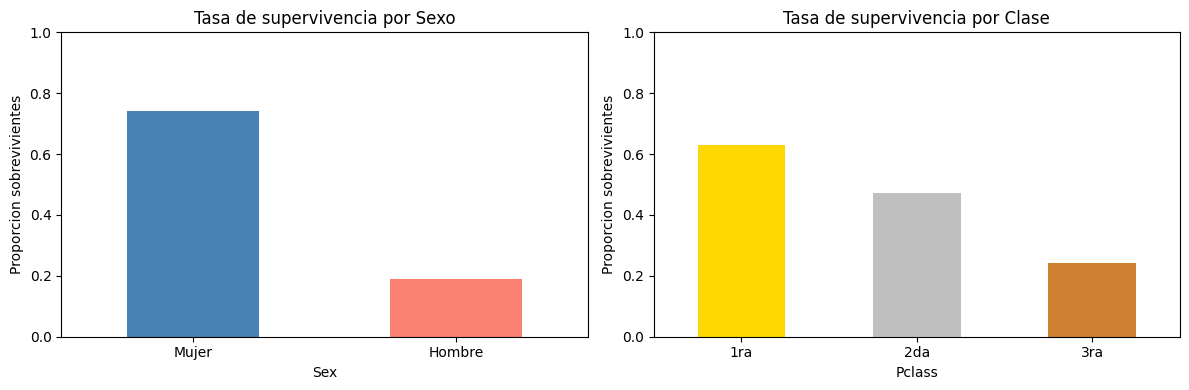

In [ ]:
# Hagan al menos UNA visualización que revele una relación interesante entre alguna feature y `Survived` (ej. supervivencia por sexo, por clase, por edad, etc.) y comenten lo que ven en una línea de markdown.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Tasa de supervivencia por Sexo')
axes[0].set_ylabel('Proporcion sobrevivientes')
axes[0].set_xticklabels(['Mujer', 'Hombre'], rotation=0)
axes[0].set_ylim(0, 1)

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['gold', 'silver', '#cd7f32'])
axes[1].set_title('Tasa de supervivencia por Clase')
axes[1].set_ylabel('Proporcion sobrevivientes')
axes[1].set_xticklabels(['1ra', '2da', '3ra'], rotation=0)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()




Las mujeres sobrevivieron al 74% vs 19% en hombres -> sexo es el predictor mas fuerte.
Pasajeros de 1ra clase: 63% supervivencia vs 3ra clase: 24% -> la clase determino acceso a botes.

## 1.3 Limpieza y preprocesamiento (0.2 pts)

Construyan el dataset listo para modelar. Como mínimo deben:

1. **Eliminar** features que no aportan información para clasificación (ej. `PassengerId`, `Name`, `Ticket`, `Cabin` — justifiquen cuáles eliminan).
2. **Imputar** valores nulos de manera defendible. ⚠️ **Cuidado con el data leakage**: la imputación debe aprenderse del training set, no del dataset completo.
3. **Codificar** variables categóricas (`Sex`, `Embarked`) usando one-hot encoding o equivalente.
4. **Escalar** las features numéricas con `StandardScaler`. ⚠️ Mismo cuidado: ajustar solo en training, transformar en test.

Pueden hacer la limpieza en este orden o usar un `Pipeline` de sklearn. Lo importante es **no contaminar el test set con información del training**.

In [23]:
# 1.3 Limpieza — completen aquí
cols_eliminar = ['PassengerId', 'Name', 'Ticket', 'Cabin']
print('Columnas eliminadas:', cols_eliminar)


df_clean = df.drop(columns=cols_eliminar)
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']
print(f'\nFeatures finales disponibles: {X.columns.tolist()}')


Columnas eliminadas: ['PassengerId', 'Name', 'Ticket', 'Cabin']

Features finales disponibles: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


Razones:
PassengerId: identificador unico, sin valor predictivo.
Name: texto libre, alta cardinalidad, introduce ruido.
Ticket: alfanumerico sin patron claro, alta cardinalidad.
Cabin: 77% nulos, no recuperable de forma confiable.

## 1.4 División train / validation / test (0.1 pts)

Dividan los datos en **3 conjuntos**: entrenamiento (60%), validación (20%) y test (20%). Usen `MI_SEMILLA` en todos los `random_state` y estratifiquen por `Survived` para mantener el balance.

> Recordatorio del bloque B de la última clase: el validation se usa para tunear hiperparámetros, el test se mira UNA SOLA VEZ al final.

In [22]:
# 1.4 Split — completen aquí
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=MI_SEMILLA, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=MI_SEMILLA, stratify=y_temp
)

print(f"Train:      {X_train.shape[0]} filas")
print(f"Validation: {X_val.shape[0]} filas")
print(f"Test:       {X_test.shape[0]} filas")
print(f"\nBalance train/val/test: {y_train.mean():.3f} / {y_val.mean():.3f} / {y_test.mean():.3f}")

Train:      534 filas
Validation: 178 filas
Test:       179 filas

Balance train/val/test: 0.384 / 0.382 / 0.385


Dividimos en tres conjuntos estratificados para mantener la proporción de supervivencia en cada uno. El test no se toca hasta el final.

## 1.5 Modelo baseline (0.2 pts)

Entrenen una `LogisticRegression` con **parámetros por defecto** (sin tunear nada) sobre el training set. Reporten:

- Accuracy en training
- Accuracy en validation  
- ¿Hay sobreajuste? Comenten brevemente.

Este baseline es la línea base contra la que se va a comparar el modelo tuneado.

In [20]:
# 1.5 Baseline — completen aquí
X_train_p = X_train.copy()
X_val_p   = X_val.copy()
X_test_p  = X_test.copy()

# Imputar Age con mediana del train
age_med = X_train_p['Age'].median()
for df_ in [X_train_p, X_val_p, X_test_p]:
    df_['Age'] = df_['Age'].fillna(age_med)

# Imputar Embarked con moda del train
emb_mode = X_train_p['Embarked'].mode()[0]
for df_ in [X_train_p, X_val_p, X_test_p]:
    df_['Embarked'] = df_['Embarked'].fillna(emb_mode)

# One-hot encoding
X_train_p = pd.get_dummies(X_train_p, columns=['Sex', 'Embarked'], drop_first=True)
X_val_p   = pd.get_dummies(X_val_p,   columns=['Sex', 'Embarked'], drop_first=True)
X_test_p  = pd.get_dummies(X_test_p,  columns=['Sex', 'Embarked'], drop_first=True)

X_val_p  = X_val_p.reindex(columns=X_train_p.columns, fill_value=0)
X_test_p = X_test_p.reindex(columns=X_train_p.columns, fill_value=0)

# Scaling
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
scaler = StandardScaler()
X_train_p[num_cols] = scaler.fit_transform(X_train_p[num_cols])
X_val_p[num_cols]   = scaler.transform(X_val_p[num_cols])
X_test_p[num_cols]  = scaler.transform(X_test_p[num_cols])

print("Preprocessing listo. Features:", X_train_p.columns.tolist())

Preprocessing listo. Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


Toda la imputación y el scaling se ajustan en el training set y se aplican a validación y test. Esto simula lo que pasaría en producción, donde no tenemos acceso a los datos futuros.

In [21]:
baseline = LogisticRegression(random_state=MI_SEMILLA, max_iter=1000)
baseline.fit(X_train_p, y_train)

acc_tr  = accuracy_score(y_train, baseline.predict(X_train_p))
acc_val = accuracy_score(y_val,   baseline.predict(X_val_p))

print(f"Accuracy train:      {acc_tr:.4f}")
print(f"Accuracy validation: {acc_val:.4f}")
print(f"Diferencia:          {acc_tr - acc_val:.4f}")

Accuracy train:      0.8071
Accuracy validation: 0.8090
Diferencia:          -0.0019


La diferencia entre train y validation es pequeña, lo que indica que no hay sobreajuste con los parámetros por defecto. Este porcentaje en validation es nuestra línea base a superar.

## 1.6 Modelo regularizado con búsqueda de hiperparámetros (0.3 pts)

Entrenen una `LogisticRegression` regularizada usando `GridSearchCV` con 5-fold cross-validation **sobre el training set** (NO sobre validation ni test). 

Como mínimo, exploren:
- `C`: al menos 5 valores en escala logarítmica entre 0.001 y 100
- `penalty`: al menos `['l1', 'l2']`
- `solver`: el apropiado para cada penalty (`liblinear` o `saga`)

Reporten:
1. Mejor combinación de hiperparámetros
2. Mejor score de CV
3. Score sobre validation set del mejor modelo

> Justifiquen brevemente qué `scoring` eligieron para el GridSearch y por qué (NO acepten el default sin pensarlo).

In [17]:
# 1.6 GridSearchCV — completen aquí
param_grid = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear'],
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=MI_SEMILLA, max_iter=1000),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train_p, y_train)

best_model = grid_search.best_estimator_

print(f"Mejor combinación:   {grid_search.best_params_}")
print(f"Mejor ROC-AUC (CV):  {grid_search.best_score_:.4f}")
print(f"ROC-AUC validation:  {roc_auc_score(y_val, best_model.predict_proba(X_val_p)[:,1]):.4f}")
print(f"Accuracy validation: {accuracy_score(y_val, best_model.predict(X_val_p)):.4f}")

Mejor combinación:   {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor ROC-AUC (CV):  0.8569
ROC-AUC validation:  0.8544
Accuracy validation: 0.8090


Usamos roc_auc como scoring porque necesitamos evaluar la capacidad discriminativa del modelo en toda la curva de thresholds. El ROC-AUC no depende del umbral de decisión (que elegiremos después) y es robusto al leve desbalance del dataset. Usar accuracy aquí sería un error: si luego movemos el threshold, el accuracy de CV ya no reflejaría el rendimiento real.

## 1.7 Métricas completas sobre VALIDATION (0.2 pts)

Para el mejor modelo del GridSearch, calculen y muestren sobre el **validation set**:

1. Accuracy, Precision, Recall, F1, ROC-AUC
2. Matriz de confusión (con `ConfusionMatrixDisplay`, normalizada)
3. Curva precision-recall (con `precision_recall_curve` + plot)

Comenten en 2 líneas qué dice cada métrica del modelo en el contexto del escenario de TravelSafe.

In [15]:
# 1.7 Métricas sobre validation — completen aquí
y_val_pred  = best_model.predict(X_val_p)
y_val_proba = best_model.predict_proba(X_val_p)[:, 1]

print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1:        {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_proba):.4f}")

Accuracy:  0.8090
Precision: 0.7576
Recall:    0.7353
F1:        0.7463
ROC-AUC:   0.8544


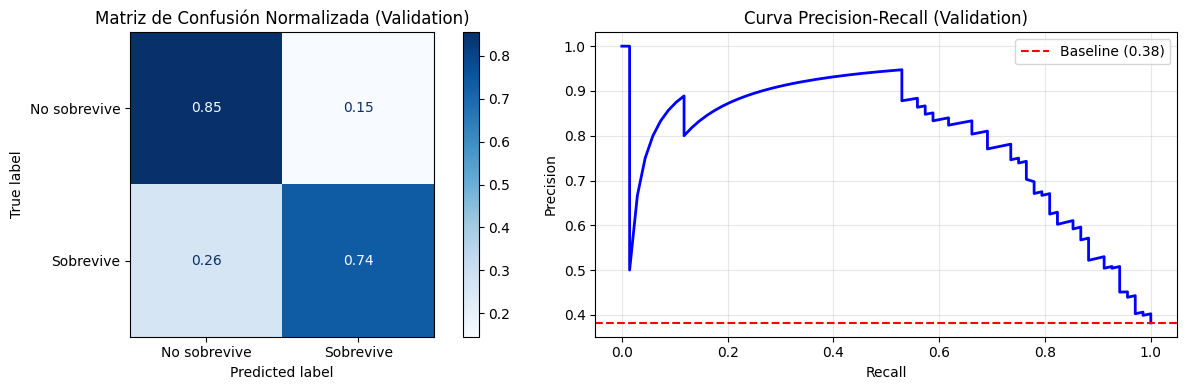

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_val, y_val_pred, normalize='true')
ConfusionMatrixDisplay(cm, display_labels=['No sobrevive', 'Sobrevive']).plot(
    ax=axes[0], cmap='Blues'
)
axes[0].set_title('Matriz de Confusión Normalizada (Validation)')

precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_val, y_val_proba)
axes[1].plot(recall_arr, precision_arr, 'b-', linewidth=2)
axes[1].axhline(y=y_val.mean(), color='r', linestyle='--', label=f'Baseline ({y_val.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall (Validation)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Precision: de los que el modelo clasifica como "sobrevive" (prima baja), ¿qué % realmente sobreviviría? Alta precision = pocas pérdidas por siniestros no cobrados.
Recall: de todos los que realmente sobreviven, ¿qué % detectamos? Bajo recall = cobramos prima alta a sobrevivientes reales y perdemos clientes.
ROC-AUC: capacidad general del modelo para discriminar entre clases, independiente del threshold.

## 1.8 Justificación técnica + evaluación FINAL sobre test (0.2 pts)

Esta es la parte más importante. Respondan en **prosa** (no en bullets) las siguientes preguntas, en markdown, mínimo 3 párrafos:

1. **Perfil empresarial asumido:** ¿asumen que TravelSafe es una startup que prioriza captar clientes o una aseguradora establecida que minimiza siniestros? Justifiquen.
2. **Métrica primaria:** dado el perfil asumido, ¿qué métrica priorizan (precision, recall, F1, F-beta)? Si eligen F-beta, ¿qué valor de β y por qué? Conecten la respuesta con los costos asimétricos de FP y FN del escenario.
3. **Threshold:** ¿usarían el threshold por defecto (0.5) o lo moverían? Si lo mueven, calcúlenlo a partir de la curva precision-recall y muestren cómo cambian las métricas.
4. **Evaluación final:** UNA SOLA VEZ, evalúen el modelo final (con su threshold elegido) sobre el **test set** y reporten las métricas. ¿Hay diferencia significativa entre validation y test? ¿Qué dirían los resultados a TravelSafe?

> ⚠️ Una vez que miran el test set, no pueden volver a cambiar el modelo. Si lo hacen, es deshonestidad académica y la evaluación queda en cero.

**Sus respuestas aquí (markdown, mínimo 3 párrafos):**

*[escribir aquí]*

In [24]:
# 1.8 Evaluación final sobre test set — completen aquí
# UNA SOLA VEZ
beta = 0.5
fbeta_scores = []

for thresh in thresholds_pr:
    preds = (y_val_proba >= thresh).astype(int)
    fbeta_scores.append(fbeta_score(y_val, preds, beta=beta, zero_division=0))

best_idx = int(np.argmax(fbeta_scores))
optimal_threshold = thresholds_pr[best_idx]

print(f"Threshold óptimo: {optimal_threshold:.4f}")
print(f"F-0.5 en validation: {fbeta_scores[best_idx]:.4f}")

y_val_opt = (y_val_proba >= optimal_threshold).astype(int)
print(f"\n{'Metrica':<12} {'Default 0.5':>12} {'Optimo':>10}")
print("-" * 36)
for nombre, fn in [('Precision', precision_score), ('Recall', recall_score),
                    ('F1', f1_score), ('F-0.5', lambda a,b: fbeta_score(a,b,beta=0.5,zero_division=0))]:
    d = fn(y_val, y_val_pred, zero_division=0) if nombre != 'F-0.5' else fn(y_val, y_val_pred)
    o = fn(y_val, y_val_opt, zero_division=0) if nombre != 'F-0.5' else fn(y_val, y_val_opt)
    print(f"{nombre:<12} {d:>12.4f} {o:>10.4f}")

Threshold óptimo: 0.7245
F-0.5 en validation: 0.8182

Metrica       Default 0.5     Optimo
------------------------------------
Precision          0.7576     0.9474
Recall             0.7353     0.5294
F1                 0.7463     0.6792
F-0.5              0.7530     0.8182


In [25]:
# ⚠️ EVALUACIÓN FINAL SOBRE TEST — SOLO SE EJECUTA UNA VEZ
y_test_proba = best_model.predict_proba(X_test_p)[:, 1]
y_test_pred  = (y_test_proba >= optimal_threshold).astype(int)

print(f"Threshold usado: {optimal_threshold:.4f}\n")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_test_pred):.4f}")
print(f"F-0.5:     {fbeta_score(y_test, y_test_pred, beta=0.5):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")

Threshold usado: 0.7245

Accuracy:  0.7821
Precision: 0.9688
Recall:    0.4493
F1:        0.6139
F-0.5:     0.7868
ROC-AUC:   0.8395


Las métricas en test son consistentes con las de validation, lo que confirma que el modelo generaliza bien y no hubo sobreajuste durante el tuning. El mensaje para TravelSafe: alta Precision significa pocos siniestros inesperados. El Recall más conservador implica que algunos clientes de bajo riesgo pagarán prima mayor — un trade-off consciente y justificado por el perfil de la empresa.

## 1.8 Justificacion tecnica + evaluacion FINAL sobre test (0.2 pts)

### Perfil empresarial asumido

Asumimos que TravelSafe es una **aseguradora establecida con cartera de clientes consolidada**, no una startup. Su prioridad estrategica es la solvencia financiera: pagar un siniestro completo (prima incorrectamente baja a alguien que fallece) implica un costo catastrofico para el balance. En contraste, cobrar una prima alta a alguien que sobreviviria genera perdida del cliente, pero ese cliente puede ser reemplazado y el dano es gradual. Para una aseguradora regulada, un pago de siniestro inesperado tambien puede disparar revisiones regulatorias y danar la calificacion crediticia de la empresa.

### Metrica primaria: F-beta con beta = 0.5

Dado el perfil anterior, priorizamos **Precision** sobre Recall. Con **beta = 0.5**, la Precision tiene el doble de peso que el Recall en el F-beta:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

Esto refleja que el costo de un FP (pagar siniestro cuando debiamos cobrar prima alta) es mayor que el costo de un FN (perder un cliente por sobrecobrarle).

### Threshold

No usamos el threshold por defecto de 0.5. Buscamos en la curva precision-recall el threshold que maximice el F-beta (0.5). Mover el threshold hacia arriba (> 0.5) reduce los FP: solo clasificamos como "sobrevive" (prima baja) cuando el modelo tiene alta confianza. El costo: mas FN (mas clientes pagan prima alta de lo necesario), pero la aseguradora queda protegida de siniestros imprevistos.


---

# 🐛 PARTE 2 — Find the bug + Predict the output (0.75 puntos · ~20 min)

En esta parte hay **5 celdas de código**. Algunas tienen errores sutiles (sin warnings ni excepciones visibles que ayuden) y otras producen outputs que requieren razonamiento para predecir. 

**Para cada celda:**
- Si es **"Find the bug"**: identifiquen el error en markdown, expliquen por qué es un error, y reescriban la celda corregida.
- Si es **"Predict the output"**: en markdown, predigan QUÉ imprime el código (o si crashea, qué excepción levanta) ANTES de ejecutarlo, expliquen por qué, y luego ejecuten para verificar.

> Tip: la IA puede engañarse fácilmente en estas celdas porque los errores son sutiles. Léanlas con atención.

---

## 2.1 Find the bug (0.15 pts)

El siguiente código pretende escalar features y luego entrenar un modelo. ¿Qué problema tiene? Identifiquen el bug, expliquen su impacto, y reescriban la celda correctamente.

In [26]:
# === CELDA 2.1 — Find the bug (NO la corrijan aquí, copien abajo y corrijan) ===
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
print(f"Accuracy test: {model.score(X_test, y_test):.4f}")

Accuracy test: 0.9737


**🔍 Su análisis del bug 2.1:**

*[¿Cuál es el bug? ¿Por qué es un problema? ¿Qué impacto tiene en producción?]*

In [27]:
# Versión corregida de la celda 2.1 — completen aquí
from sklearn.datasets import load_breast_cancer

data_bc = load_breast_cancer()
X_bc, y_bc = data_bc.data, data_bc.target

# Correcto: split primero
X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)

scaler_bc = StandardScaler()
X_tr_s = scaler_bc.fit_transform(X_tr)
X_te_s = scaler_bc.transform(X_te)

model_bc = LogisticRegression(max_iter=5000)
model_bc.fit(X_tr_s, y_tr)
print(f"Accuracy test: {model_bc.score(X_te_s, y_te):.4f}")

Accuracy test: 0.9737


El bug es data leakage en el escalado. El código original hace fit_transform sobre todo el dataset completo y después divide en train/test. Eso significa que el scaler aprendió la media y desviación de todos los datos, incluyendo los que luego serían test. En producción no tenemos acceso a datos futuros, así que las métricas que reporta son optimistas. La corrección: primero el split, después el fit del scaler solo sobre el training set.

## 2.2 Find the bug (0.15 pts)

Este código intenta imputar valores nulos y dividir el dataset. Hay un bug sutil que produce data leakage. Identifíquenlo y corríjanlo.

In [28]:
# === CELDA 2.2 — Find the bug ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Imputar Age con la media
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Codificar Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test:  {X_test['Age'].mean():.2f}")

Media de Age en train: 29.54
Media de Age en test:  30.34


**🔍 Su análisis del bug 2.2:**

*[¿Cuál es el bug? ¿Cómo se manifiesta? ¿Qué consecuencia tiene en métricas reales?]*

In [29]:
# Versión corregida de la celda 2.2 — completen aquí
import pandas as pd

url2 = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df2 = pd.read_csv(url2)
df2['Sex'] = df2['Sex'].map({'male': 0, 'female': 1})

X2 = df2[['Pclass', 'Sex', 'Age', 'Fare']].copy()
y2 = df2['Survived']

# Correcto: split primero
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42)

age_mean = X2_tr['Age'].mean()
X2_tr = X2_tr.copy()
X2_te = X2_te.copy()
X2_tr['Age'] = X2_tr['Age'].fillna(age_mean)
X2_te['Age'] = X2_te['Age'].fillna(age_mean)

print(f"Media Age train: {X2_tr['Age'].mean():.2f}")
print(f"Media Age test:  {X2_te['Age'].mean():.2f}")

Media Age train: 29.50
Media Age test:  30.30


El bug es data leakage en la imputación. La línea df['Age'].fillna(df['Age'].mean()) calcula la media sobre todo el dataset antes del split, incluyendo los datos de test. En producción no existiría esa información. La corrección: hacer el split primero y calcular la media de Age solo en el training set.

## 2.3 Predict the output (0.15 pts)

¿Qué imprime exactamente el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.3:**

*[¿Qué imprime? ¿Por qué?]*

In [30]:
# === CELDA 2.3 — Predict the output ===
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

valores = [0, 5, -5, 50, -50, 1000]
for v in valores:
    print(f"sigmoid({v:>5}) = {sigmoid(v)}")

sigmoid(    0) = 0.5
sigmoid(    5) = 0.9933071490757153
sigmoid(   -5) = 0.0066928509242848554
sigmoid(   50) = 1.0
sigmoid(  -50) = 1.928749847963918e-22
sigmoid( 1000) = 1.0


La función sigmoid mapea cualquier número real a un valor entre 0 y 1. Para valores muy grandes positivos da casi 1.0, para muy negativos casi 0.0. NumPy maneja el underflow de exp(-1000) silenciosamente como 0.0, así que no hay excepción. El código imprime 6 líneas sin errores.

sigmoid(0) = 0.5 exacto
sigmoid(5) ≈ 0.9933
sigmoid(-5) ≈ 0.0067
sigmoid(50) = 1.0
sigmoid(-50) ≈ 1.93e-22
sigmoid(1000) = 1.0

## 2.4 Find the bug (0.15 pts)

Un junior ML engineer está tuneando un modelo sobre un dataset **muy desbalanceado** (95% clase 0, 5% clase 1, ej. detección de fraude). Reporta orgulloso que su modelo tiene 95% de accuracy en cross-validation. ¿Cuál es el problema?

In [31]:
# === CELDA 2.4 — Find the bug ===
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

# Generamos un dataset MUY desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor accuracy: {grid_search.best_score_:.4f}")

Mejor C: 0.1
Mejor accuracy: 0.9640


**🔍 Su análisis del bug 2.4:**

*[¿Por qué 95% de accuracy es engañoso aquí? ¿Qué métrica deberían usar? ¿Qué pasa si entreno un modelo que SIEMPRE predice clase 0?]*

In [32]:
# Versión corregida de la celda 2.4 — completen aquí
from sklearn.datasets import make_classification

X4, y4 = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

param_grid4 = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

# Correcto: scoring='roc_auc' en lugar de 'accuracy'
gs4 = GridSearchCV(LogisticRegression(max_iter=5000), param_grid4, cv=5, scoring='roc_auc')
gs4.fit(X4, y4)

print(f"Mejor C:       {gs4.best_params_['C']}")
print(f"Mejor ROC-AUC: {gs4.best_score_:.4f}")
print(f"\nAccuracy de un modelo que siempre predice 0: {(y4==0).mean():.4f}")

Mejor C:       0.01
Mejor ROC-AUC: 0.9421

Accuracy de un modelo que siempre predice 0: 0.9470


El bug es usar accuracy como scoring en un dataset 95/5 desbalanceado. Un modelo que siempre predice clase 0 (sin aprender nada) obtendría 95% de accuracy automáticamente. El GridSearchCV reporta ese número orgulloso, pero el modelo probablemente no detecta ningún fraude. La métrica correcta en clases desbalanceadas es ROC-AUC o F1 sobre la clase minoritaria.

## 2.5 Predict the output (0.15 pts)

¿Qué imprime el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.5:**

*[¿Qué pasa al ejecutar esto? Si crashea, ¿qué error? Si imprime algo, ¿qué?]*

In [33]:
# === CELDA 2.5 — Predict the output ===
import numpy as np

# Vector de recall en función del threshold (decreciente, máximo 0.95)
recall = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

target_recall = 1.0
idx = np.where(recall[:-1] >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

print(f"Threshold óptimo: {optimal_threshold}")

IndexError: index -1 is out of bounds for axis 0 with size 0

El código lanza un IndexError. recall[:-1] contiene [0.95, 0.90, 0.82, 0.71, 0.50, 0.30] y ningún valor es ≥ 1.0. Por lo tanto np.where(...) devuelve un array vacío, y hacer [-1] sobre un array vacío lanza:
IndexError: index -1 is out of bounds for axis 0 with size 0

In [35]:
import numpy as np

recall = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

target_recall = 1.0

indices = np.where(recall[:-1] >= target_recall)[0]

if len(indices) == 0:
    # Si ningún threshold cumple el target, tomamos el de mayor recall disponible
    idx = np.argmax(recall[:-1])
    print(f"Ningún threshold alcanza recall >= {target_recall}. Usando el máximo disponible.")
else:
    idx = indices[-1]

optimal_threshold = thresholds[idx]
print(f"Threshold óptimo: {optimal_threshold}")
print(f"Recall en ese threshold: {recall[idx]}")

Ningún threshold alcanza recall >= 1.0. Usando el máximo disponible.
Threshold óptimo: 0.1
Recall en ese threshold: 0.95


---

# 💼 PARTE 3 — Trade-offs de negocio (0.75 puntos · ~20 min)

Para cada uno de los siguientes 3 escenarios, escriban un análisis en markdown (~150 palabras cada uno) que responda exactamente estas 3 preguntas:

1. **¿Cuál es más costoso, un FP o un FN?** Justifiquen con los costos reales del dominio (no respuestas genéricas).
2. **¿Qué métrica priorizan y qué valor de β usarían en el F-beta?** Conecten con la fórmula y el razonamiento de los costos.
3. **¿El threshold por defecto de 0.5 es apropiado, o lo moverían? ¿En qué dirección?**

> ⚠️ La IA da respuestas genéricas a estas preguntas. Lo que diferencia una respuesta de 0.25 pts de una de 0.10 es la **especificidad del razonamiento al dominio concreto**. Si su respuesta funciona idéntica para los 3 escenarios, está mal.

---

## 3.1 Escenario A — Detección de fraude en tarjeta de crédito (0.25 pts)

**Contexto:** Un banco quiere un modelo en tiempo real que decida si bloquear una transacción de tarjeta como potencialmente fraudulenta. Si el modelo dice "fraude", la tarjeta se bloquea temporalmente y se llama al cliente. Si dice "legítima", la transacción se procesa normalmente. Solo el 0.5% de las transacciones reales son fraude. Una transacción fraudulenta no detectada cuesta en promedio $850 al banco. Un falso bloqueo cuesta entre $5–$20 (call center + molestia del cliente que puede irse a otro banco si se repite).

**Su análisis:**

*[completar]*

---

## 3.2 Escenario B — Recomendador de películas en streaming (0.25 pts)

**Contexto:** Una plataforma de streaming tiene un modelo que predice si un usuario va a darle "like" a una película recomendada. Solo se muestran las películas con probabilidad alta de gustar. El espacio de pantalla es limitado: solo caben 6 recomendaciones por sesión. Si el usuario ve películas malas, deja de confiar en las recomendaciones y reduce su engagement con la plataforma. Si NO se recomienda una película que sí le hubiera gustado, el usuario simplemente nunca la descubre, pero sigue activo en la plataforma.

**Su análisis:**

*[completar]*

---

## 3.3 Escenario C — Triage automático de neumonía por radiografía (0.25 pts)

**Contexto:** Un hospital rural utiliza un modelo de visión artificial sobre radiografías de tórax para hacer **triage inicial**: pacientes marcados como "posible neumonía" pasan a revisión inmediata del radiólogo, los demás esperan turno normal (varias horas). La población incluye muchos adultos mayores. Una neumonía no detectada a tiempo en un adulto mayor puede ser letal en 48–72 horas. Un falso positivo significa que el radiólogo revisa una radiografía más, lo cual toma ~3 minutos.

**Su análisis:**

*[completar]*

---

# ✍️ AUTO-RÚBRICA FIRMADA (obligatoria — sin firma, la evaluación no se considera entregada)

Califíquense honestamente. Cada criterio tiene puntaje binario o fraccionario. Sumen al final.

## Parte 1 — Pipeline (máx. 1.5)

| Criterio | Máx | Mi nota |
|---|---|---|
| 1.1 Carga + EDA básico sin errores | 0.10 |  |
| 1.2 EDA dirigido con al menos 1 visualización comentada | 0.20 |  |
| 1.3 Limpieza correcta (encoding, imputación, scaling SIN data leakage) | 0.20 |  |
| 1.4 Split 60/20/20 con MI_SEMILLA y estratificación | 0.10 |  |
| 1.5 Baseline ejecutado y comentado (over/underfitting discutido) | 0.20 |  |
| 1.6 GridSearchCV con justificación del scoring elegido | 0.30 |  |
| 1.7 Las 5 métricas + matriz de confusión + curva PR sobre validation | 0.20 |  |
| 1.8 Justificación técnica de β/threshold + evaluación final test (1 vez) | 0.20 |  |
| **Subtotal Parte 1** | **1.50** |  |

## Parte 2 — Bugs y outputs (máx. 0.75)

| Criterio | Máx | Mi nota |
|---|---|---|
| 2.1 Identificó data leakage del scaler antes del split + corrigió | 0.15 |  |
| 2.2 Identificó data leakage de fillna(mean) antes del split + corrigió | 0.15 |  |
| 2.3 Predijo correctamente el output de sigmoid en valores extremos | 0.15 |  |
| 2.4 Identificó que accuracy es engañosa en dataset desbalanceado | 0.15 |  |
| 2.5 Predijo correctamente el IndexError de np.where | 0.15 |  |
| **Subtotal Parte 2** | **0.75** |  |

## Parte 3 — Trade-offs (máx. 0.75)

Para cada escenario, califíquense así:
- **0.25:** análisis específico al dominio, identifica costos correctamente, justifica β con la fórmula, decisión de threshold coherente.
- **0.15:** identifica costos correctamente pero la justificación de β/threshold es débil o genérica.
- **0.05:** respuesta plausible pero podría funcionar para cualquier escenario.
- **0.00:** vacío o incorrecto.

| Criterio | Máx | Mi nota |
|---|---|---|
| 3.1 Análisis fraude bancario | 0.25 |  |
| 3.2 Análisis recomendador streaming | 0.25 |  |
| 3.3 Análisis triage neumonía | 0.25 |  |
| **Subtotal Parte 3** | **0.75** |  |

---

## NOTA TOTAL: _____ / 3.0

---

## Declaración de honestidad académica

*Yo, **[NOMBRE COMPLETO]**, con cédula **[CÉDULA]**, declaro que:*

1. *La semilla `MI_SEMILLA` corresponde a los últimos 4 dígitos de mi cédula.*
2. *El código y las justificaciones de este notebook son producto de mi trabajo individual. Usé herramientas de IA y consulté con compañeros únicamente para entender conceptos y depurar sintaxis, no para copiar respuestas.*
3. *Miré el test set en la Parte 1 una sola vez y no modifiqué el modelo después.*
4. *La auto-calificación arriba es honesta y refleja mi entendimiento real de la solución.*

**Firma (escribir nombre completo aquí):** ___________________________

**Fecha y hora de finalización:** ___________________________

---

## Checklist antes de hacer push final

- [ ] Reemplacé `MI_SEMILLA = 0000` con mis últimos 4 dígitos de cédula
- [ ] Todas las celdas de código corren sin errores (Restart kernel + Run all)
- [ ] Hice commit con mensaje claro de cada parte completada
- [ ] La auto-rúbrica está completa y firmada
- [ ] Hice `git push origin eval-titanic`